
# 64x16x64 Autoencoder (Digits Dataset)


In [1]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from nn import nn

## Load and Prepare the Digits Dataset
- Load the digits dataset through sklearn using sklearn.datasets.load_digits()
- Split the data into training and validation sets.

In [2]:

digits = load_digits()
X = digits.data / 16.0

X_train, X_val = train_test_split(X, test_size=0.2, random_state=42)

y_train = X_train.copy()
y_val = X_val.copy()

print(X_train.shape, X_val.shape)


(1437, 64) (360, 64)


## Build the 64→16→64 Autoencoder
- Generate an instance of your NeuralNetwork class with a 64x16x64 autoencoder architecture.

In [3]:

arch = [
    {"input_dim":64, "output_dim":16, "activation":"relu"},
    {"input_dim":16, "output_dim":64, "activation":"sigmoid"}
]

model = nn.NeuralNetwork(
    nn_arch=arch,
    lr=0.1,
    seed=42,
    batch_size=32,
    epochs=50,
    loss_function="mean_squared_error"
)


## Train the Autoencoder
- Train your autoencoder on the training data.

In [4]:

train_loss, val_loss = model.fit(X_train, y_train, X_val, y_val)


## Plot Training and Validation Loss
- Plot your training and validation loss by epoch.

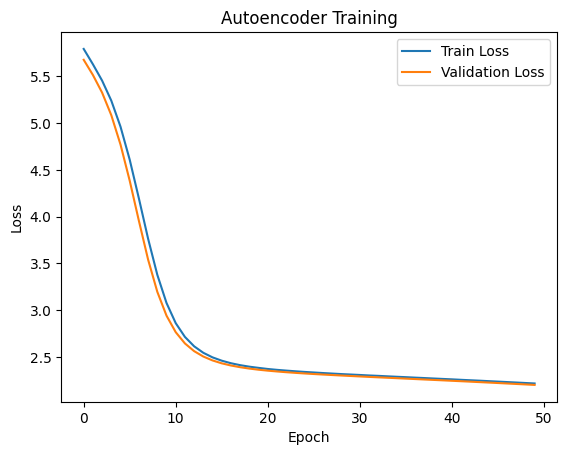

In [5]:

plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Autoencoder Training")
plt.legend()
plt.show()


## Compute Reconstruction Error
- Quantify your average reconstruction error over the validation set.
- Explain why you chose the hyperparameter values you did.

In [6]:

recon = model.predict(X_val)
mse = np.mean((recon - X_val)**2)
print("Average reconstruction error:", mse)


Average reconstruction error: 0.06878069893365758



## Explanation of Loss Function and Hyperparameters

**Loss function**: 
- I used mean squared error because it is appropriate for reconstruction tasks where we need to compare pixel values between the original and reconstructed images.

**Hyperparameters**:
- Learning rate = 0.1: allows for fast convergence on small digits dataset.
- Batch size = 32: seems like a reasonable minibatch size for stable gradient estimates and computational efficiency.
- Epochs = 50: was sufficient to observe convergence.
